# EDA: Hugging Face `dsaint31/hf_maloccu` — Malocclusal Occlusal Image Dataset

Dataset ketiga untuk eksplorasi — beda dari `omni_coco` dan `Malocclusion-Data` (Roboflow): dataset ini **punya label Angle Classification langsung** (`Angle Class 1/2/3`), jadi ini yang paling relevan untuk task klasifikasi Angle yang sempat kita diskusikan sebelumnya (waktu itu `omni_coco` tidak mendukung task ini sama sekali).

> **PENTING — catatan lisensi:** README dataset ini menyatakan eksplisit *"Internal Use Only... Redistribution or external use is prohibited"* / *"Proprietary – Internal use only"*, meskipun repo-nya bisa diakses publik tanpa token. Notebook ini dipakai untuk eksplorasi riset internal saja — **jangan redistribusikan/publish ulang data atau turunannya** tanpa izin eksplisit dari pemilik dataset.

**Struktur dataset** (2 konfigurasi, sama-sama tersedia dalam 1 repo, split `train`/`validation`/`test`, **displit per pasien** — sudah diverifikasi tidak ada leakage):

- **`default` (pairwise)** — 1 baris = sepasang gambar oklusal kanan+kiri (`image_r`, `image_l`), masing-masing punya label Angle Class sendiri (`class_r`, `class_l`) dan nilai jarak kontinu (`dist_r`, `dist_l`)
- **`single_image`** — hasil "explode" dari pairwise, 1 baris = 1 gambar (`image`) + sisi (`side`) + 1 label (`labels`) + 1 jarak (`dist`)

**Tujuan notebook:** pahami ukuran & struktur dataset, distribusi kelas Angle (per sisi & per split), hubungan `dist` (jarak kontinu) dengan kelas Angle diskrit, distribusi `tx_phase` (Pre-Tx/Post-Tx), verifikasi tidak ada leakage pasien, dan visualisasi sampel gambar.

## 1. Setup

In [2]:
%pip install -q datasets pyarrow huggingface_hub


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
from pathlib import Path

# Workaround: ~/.cache/huggingface/hub di beberapa mesin kepemilikannya "root" (biasanya bekas
# `sudo pip install` di masa lalu), jadi user biasa nggak bisa nulis ke situ -> PermissionError.
# Redirect cache Hugging Face ke folder lokal proyek yang jelas dimiliki user, supaya nggak perlu
# sudo/ubah permission sistem. Harus di-set SEBELUM import `datasets`/`huggingface_hub`.
HF_CACHE_DIR = Path("../.hf_cache").resolve()
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(HF_CACHE_DIR)

import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

REPO_ID = "dsaint31/hf_maloccu"
SPLITS = ["train", "validation", "test"]
ANGLE_CLASS_NAMES = ["Angle Class 1", "Angle Class 2", "Angle Class 3"]


## 2. Load dataset (kedua konfigurasi)

`load_dataset` otomatis download & cache parquet dari Hugging Face Hub (butuh koneksi internet saat pertama kali dijalankan, sekitar ~110MB total). Konfigurasi `default` (pairwise) dan `single_image` sama-sama dimuat.

In [5]:
ds_pair = load_dataset(REPO_ID)          # config "default" (pairwise: image_r + image_l)
ds_single = load_dataset(REPO_ID, "single_image")  # config "single_image" (hasil explode)

print(ds_pair)
print()
print(ds_single)


README.md:   0%|          | 0.00/6.62k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 33.4MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.5MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

single_image/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2342 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/780 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/780 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['row_id', 'patient_id', 'tx_phase', 'image_r', 'image_l', 'class_r', 'class_l', 'dist_r', 'dist_l', 'idx'],
        num_rows: 1171
    })
    validation: Dataset({
        features: ['row_id', 'patient_id', 'tx_phase', 'image_r', 'image_l', 'class_r', 'class_l', 'dist_r', 'dist_l', 'idx'],
        num_rows: 390
    })
    test: Dataset({
        features: ['row_id', 'patient_id', 'tx_phase', 'image_r', 'image_l', 'class_r', 'class_l', 'dist_r', 'dist_l', 'idx'],
        num_rows: 390
    })
})

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'tx_phase', 'image', 'side', 'labels', 'dist', 'parent_row_id', 'parent_idx'],
        num_rows: 2342
    })
    validation: Dataset({
        features: ['patient_id', 'tx_phase', 'image', 'side', 'labels', 'dist', 'parent_row_id', 'parent_idx'],
        num_rows: 780
    })
    test: Dataset({
        features: ['patient_id', 'tx_phase', 'image', 'side', 'labels', 'dist', 'p

### 2.1 Skema kolom

Cek langsung ke `.features`, karena ada sedikit perbedaan dengan yang ditulis di README dataset (mis. kolom `labels` bukan `label`, dan `side` ternyata `ClassLabel(['right','left'])`, bukan string mentah `"r"/"l"`).

In [6]:
print("=== default (pairwise) ===")
for k, v in ds_pair["train"].features.items():
    print(f"  {k}: {v}")

print()
print("=== single_image ===")
for k, v in ds_single["train"].features.items():
    print(f"  {k}: {v}")


=== default (pairwise) ===
  row_id: Value('int32')
  patient_id: Value('string')
  tx_phase: Value('string')
  image_r: Image(mode=None, decode=True)
  image_l: Image(mode=None, decode=True)
  class_r: ClassLabel(names=['Angle Class 1', 'Angle Class 2', 'Angle Class 3'])
  class_l: ClassLabel(names=['Angle Class 1', 'Angle Class 2', 'Angle Class 3'])
  dist_r: Value('float32')
  dist_l: Value('float32')
  idx: Value('int32')

=== single_image ===
  patient_id: Value('string')
  tx_phase: Value('string')
  image: Image(mode=None, decode=True)
  side: ClassLabel(names=['right', 'left'])
  labels: ClassLabel(names=['Angle Class 1', 'Angle Class 2', 'Angle Class 3'])
  dist: Value('float32')
  parent_row_id: Value('int32')
  parent_idx: Value('int32')


## 3. Ringkasan ukuran dataset per split

In [7]:
summary_rows = []
for split in SPLITS:
    d = ds_pair[split]
    summary_rows.append({
        "split": split,
        "n_rows_pairwise": len(d),
        "n_rows_single": len(ds_single[split]),
        "n_unique_patients": len(set(d["patient_id"])),
    })

summary = pd.DataFrame(summary_rows).set_index("split")
summary


,n_rows_pairwise,n_rows_single,n_unique_patients
split,,,
train,1171,2342,604
validation,390,780,195
test,390,780,195


In [8]:
print(f"Total baris (pairwise) : {sum(len(ds_pair[s]) for s in SPLITS)}")
print(f"Total baris (single)   : {sum(len(ds_single[s]) for s in SPLITS)}")
print(f"Total pasien unik      : {len(set().union(*[set(ds_pair[s]['patient_id']) for s in SPLITS]))}")


Total baris (pairwise) : 1951
Total baris (single)   : 3902
Total pasien unik      : 994


## 4. Verifikasi split per pasien (cek leakage)

README dataset ini eksplisit klaim semua sample dari `patient_id` yang sama selalu di split yang sama. Kita verifikasi langsung, sama seperti yang dilakukan untuk `omni_coco`.

In [9]:
patient_sets = {split: set(ds_pair[split]["patient_id"]) for split in SPLITS}

print("train ∩ validation :", patient_sets["train"] & patient_sets["validation"])
print("train ∩ test       :", patient_sets["train"] & patient_sets["test"])
print("validation ∩ test  :", patient_sets["validation"] & patient_sets["test"])


train ∩ validation : set()
train ∩ test       : set()
validation ∩ test  : set()


### 4.1 Jumlah baris per pasien

Dataset longitudinal (ada `tx_phase` Pre-Tx/Post-Tx) — cek berapa kali rata-rata satu pasien muncul (1x kalau cuma salah satu fase, 2x kalau ada data Pre-Tx dan Post-Tx).

In [10]:
for split in SPLITS:
    counts = Counter(ds_pair[split]["patient_id"])
    dist = Counter(counts.values())
    print(f"[{split}] distribusi jumlah baris per pasien: {dict(sorted(dist.items()))}")


[train] distribusi jumlah baris per pasien: {1: 37, 2: 567}
[validation] distribusi jumlah baris per pasien: {2: 195}
[test] distribusi jumlah baris per pasien: {2: 195}


## 5. Cek integritas gambar

Ukuran & mode warna (README bilang grayscale PNG) — cek konsisten atau tidak, di seluruh split dan kedua sisi (`image_r`/`image_l`).

In [11]:
sizes = set()
modes = set()
for split in SPLITS:
    d = ds_pair[split]
    for i in range(len(d)):
        row = d[i]
        for key in ["image_r", "image_l"]:
            sizes.add(row[key].size)
            modes.add(row[key].mode)

print("Ukuran gambar unik (width, height):", sizes)
print("Mode warna unik:", modes)


Ukuran gambar unik (width, height): {(224, 205)}
Mode warna unik: {'L'}


## 6. Distribusi kelas Angle

`class_r`/`class_l` (0=Angle Class 1, 1=Angle Class 2, 2=Angle Class 3) — cek imbalance, dan apakah distribusi sisi kanan vs kiri mirip.

In [12]:
cls_rows = []
for split in SPLITS:
    d = ds_pair[split]
    cr = Counter(d["class_r"])
    cl = Counter(d["class_l"])
    for i, name in enumerate(ANGLE_CLASS_NAMES):
        cls_rows.append({"split": split, "side": "right", "class": name, "count": cr.get(i, 0)})
        cls_rows.append({"split": split, "side": "left", "class": name, "count": cl.get(i, 0)})

df_cls = pd.DataFrame(cls_rows)
pivot_cls = df_cls.pivot_table(index=["class"], columns=["split", "side"], values="count", aggfunc="sum")
pivot_cls


split         test       train       validation      
side          left right  left right       left right
class                                                
Angle Class 1  178   183   468   483        168   178
Angle Class 2   89   108   341   377        106   110
Angle Class 3  123    99   362   311        116   102

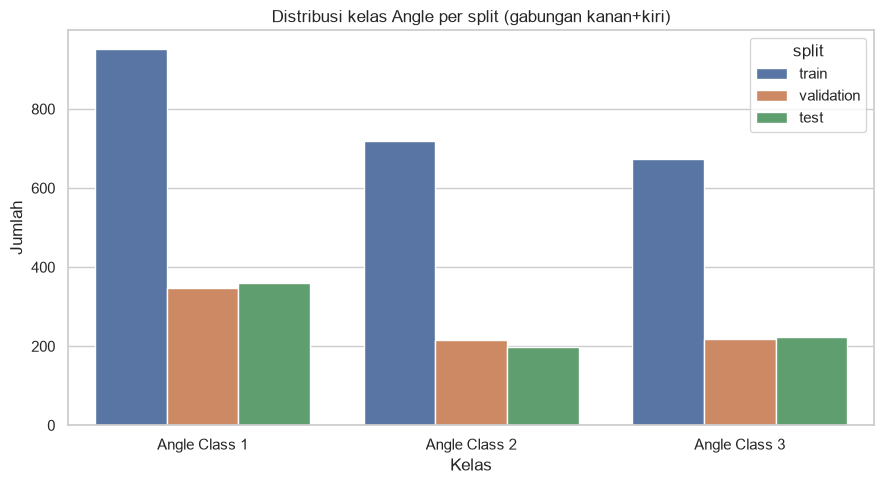

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_cls, x="class", y="count", hue="split", ax=ax, errorbar=None,
            estimator=sum, order=ANGLE_CLASS_NAMES)
ax.set_title("Distribusi kelas Angle per split (gabungan kanan+kiri)")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah")
plt.tight_layout()
plt.show()


## 7. `dist` — jarak kontinu di balik kelas Angle

`dist_r`/`dist_l` adalah nilai kontinu (kemungkinan besar jarak molar relatif secara klinis) yang mendasari klasifikasi Angle diskrit. Kita lihat sebarannya per kelas — idealnya kelas Angle 2 (distal) condong ke nilai positif tinggi, kelas 3 (mesial) condong negatif, kelas 1 (normal) di sekitar nol, mengikuti konvensi klinis standar.

In [14]:
dist_rows = []
for split in SPLITS:
    d = ds_pair[split]
    for i in range(len(d)):
        row = d[i]
        dist_rows.append({"split": split, "side": "right", "class": ANGLE_CLASS_NAMES[row["class_r"]], "dist": row["dist_r"]})
        dist_rows.append({"split": split, "side": "left", "class": ANGLE_CLASS_NAMES[row["class_l"]], "dist": row["dist_l"]})

df_dist = pd.DataFrame(dist_rows)
df_dist.groupby("class")["dist"].describe()


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Angle Class 1,1658.0,0.620573,0.608085,-1.23,0.20,0.615,1.030,4.390000
Angle Class 2,1131.0,4.081477,2.531601,-5.80,2.02,3.420,6.095,25.120001
Angle Class 3,1113.0,-2.313369,2.685677,-24.48,-3.18,-1.350,-0.580,2.690000


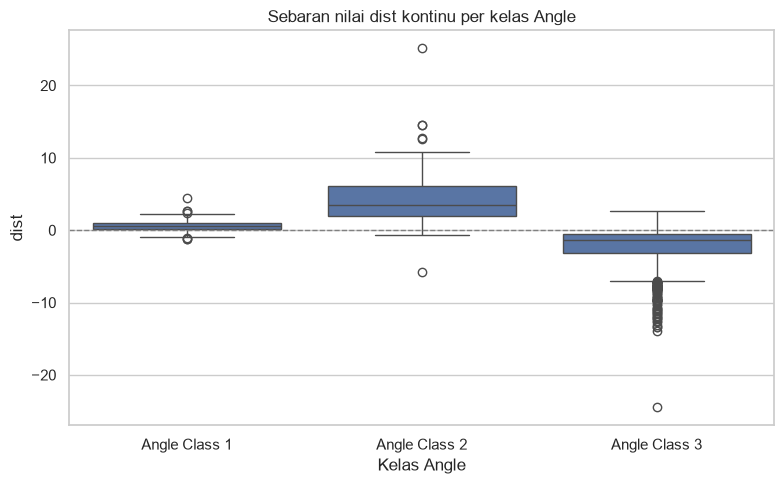

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_dist, x="class", y="dist", order=ANGLE_CLASS_NAMES, ax=ax)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Sebaran nilai dist kontinu per kelas Angle")
ax.set_xlabel("Kelas Angle")
ax.set_ylabel("dist")
plt.tight_layout()
plt.show()


## 8. Distribusi `tx_phase` (Pre-Tx vs Post-Tx)

In [16]:
tx_rows = []
for split in SPLITS:
    counts = Counter(ds_pair[split]["tx_phase"])
    for phase, n in counts.items():
        tx_rows.append({"split": split, "tx_phase": phase, "count": n})

df_tx = pd.DataFrame(tx_rows).pivot(index="tx_phase", columns="split", values="count").fillna(0).astype(int)
df_tx


split,test,train,validation
tx_phase,,,
Post-Tx,195,592,195
Pre-Tx,195,579,195


## 9. Visualisasi sampel

Beberapa pasangan gambar oklusal kanan-kiri dari train, dengan label kelas Angle dan nilai `dist` masing-masing sisi.

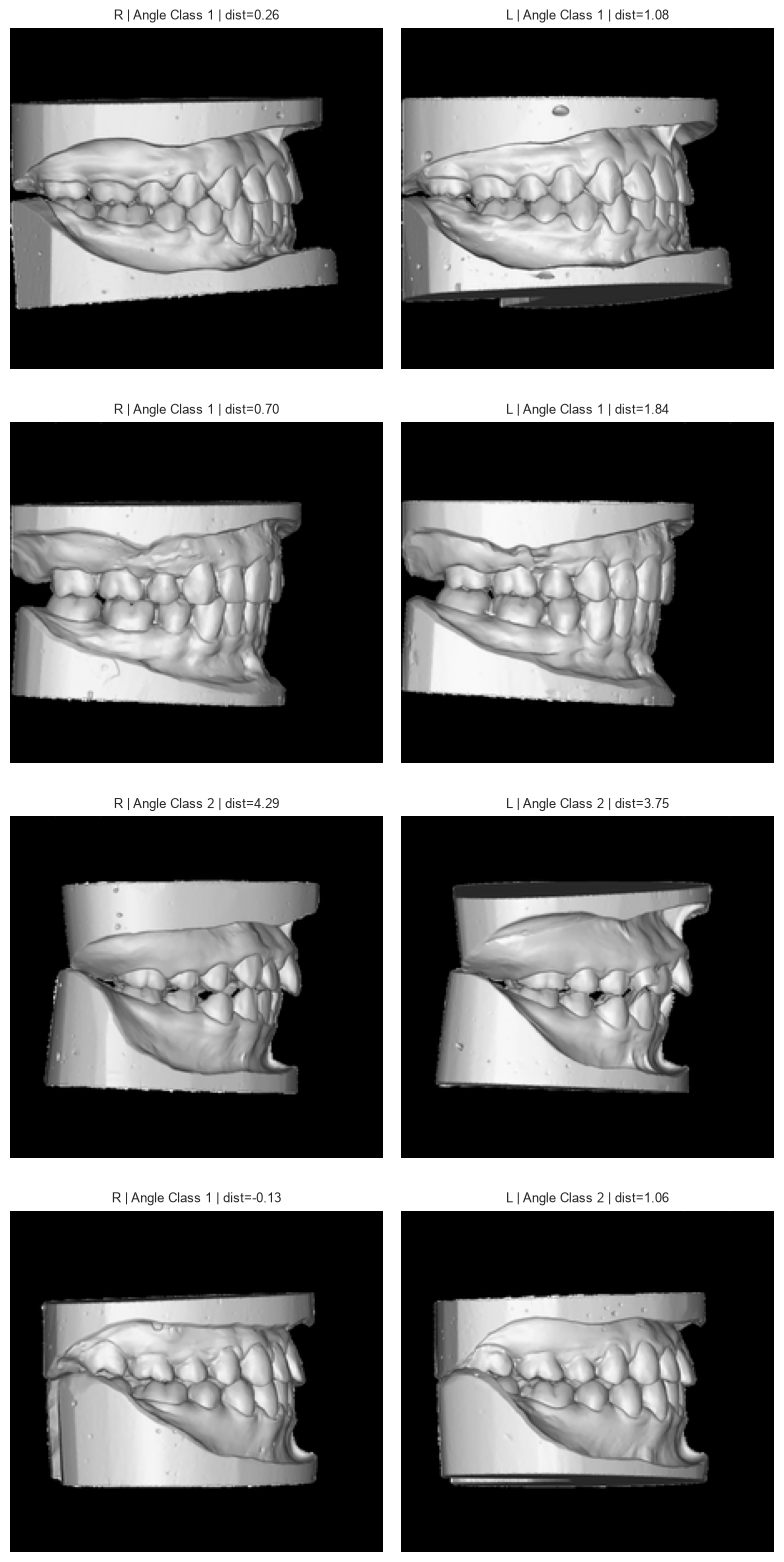

In [17]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(ds_pair["train"]), size=4, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(8, 16))
for row_i, idx in enumerate(sample_idx):
    row = ds_pair["train"][int(idx)]
    axes[row_i, 0].imshow(row["image_r"], cmap="gray")
    axes[row_i, 0].set_title(f"R | {ANGLE_CLASS_NAMES[row['class_r']]} | dist={row['dist_r']:.2f}", fontsize=9)
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(row["image_l"], cmap="gray")
    axes[row_i, 1].set_title(f"L | {ANGLE_CLASS_NAMES[row['class_l']]} | dist={row['dist_l']:.2f}", fontsize=9)
    axes[row_i, 1].axis("off")

plt.tight_layout()
plt.show()


## 10. Catatan / temuan awal

**Ukuran & integritas data**
- 1951 baris pairwise (1171 train / 390 validation / 390 test) = 3902 baris di config `single_image`, dari 994 pasien unik total.
- Gambar seragam 224×205, grayscale (`mode='L'`) di seluruh dataset — tidak perlu resize/normalisasi ukuran seperti dua dataset sebelumnya.
- Split per-pasien **sudah diverifikasi tidak ada leakage** (train∩validation, train∩test, validation∩test semuanya himpunan kosong) — konsisten dengan klaim README.
- Mayoritas pasien (567 dari 604 di train) punya 2 baris (Pre-Tx & Post-Tx) — dataset ini longitudinal per pasien, bukan snapshot tunggal.

**Distribusi kelas Angle — jauh lebih seimbang dibanding `omni_coco`/Roboflow**
- Gabungan kanan+kiri, semua split: Angle Class 1 = 1658 (42.5%), Class 2 = 1131 (29.0%), Class 3 = 1113 (28.5%).
- Beda jauh dari `omni_coco` (kelas terbesar 62%, terkecil 0.3%) dan dataset Roboflow (kelas terbesar vs terkecil rasio puluhan kali) — dataset ini tidak butuh penanganan class imbalance seberat itu, meski Class 1 tetap sedikit lebih dominan.
- Proporsi antar split (train/val/test) juga konsisten satu sama lain, jadi imbalance-nya (yang memang ringan) bukan artefak split.

**`dist` (jarak kontinu) vs kelas Angle — pola klinis yang masuk akal, tapi ada overlap**
- Class 1 (normal): mean 0.62, rentang [-1.23, 4.39] — terkumpul dekat nol.
- Class 2 (distal): mean 4.08, rentang [-5.80, 25.12] — condong ke nilai positif tinggi.
- Class 3 (mesial): mean -2.31, rentang [-13.41 s/d -24.48, 2.69] — condong ke nilai negatif.
- Arah rata-ratanya konsisten dengan konvensi klinis Angle classification standar (Class 2 = relasi distal/positif, Class 3 = relasi mesial/negatif). Tapi **rentang antar kelas saling overlap** (mis. Class 3 bisa sampai +2.69, tumpang tindih dengan rentang bawah Class 1) — jadi `dist` bukan prediktor sempurna kelas Angle lewat threshold sederhana, ada faktor lain yang menentukan label akhirnya (atau ada noise pengukuran).

**`tx_phase` seimbang**
- Pre-Tx vs Post-Tx nyaris 50/50 di semua split (val & test malah persis 195/195). Bagus untuk analisis progres treatment kalau dibutuhkan nanti, tanpa bias ke salah satu fase.

**Posisi dataset ini dibanding dua dataset sebelumnya**
- `omni_coco`: deteksi objek per-gigi, tidak ada label Angle sama sekali.
- Roboflow `Malocclusion-Data`: kelas region/kuadran (kode `1`/`2a`.../`5s`), juga tidak ada label Angle, dan datasetnya sangat kecil (626 gambar) untuk 30 kelas.
- **Dataset ini** — satu-satunya dari ketiganya yang punya **label Angle Class langsung**, ukurannya lebih besar untuk task klasifikasi (1951-3902 sample tergantung config), dan class balance jauh lebih baik. Kandidat paling kuat kalau tujuan akhirnya memang klasifikasi Angle.

**Yang masih perlu diputuskan/diverifikasi**
- Pilih config mana yang dipakai untuk training: `default` (pairwise, model bisa belajar dari kanan+kiri sekaligus per pasien) vs `single_image` (lebih sederhana, tapi kehilangan informasi pasangan kanan-kiri per kunjungan).
- Overlap rentang `dist` antar kelas (lihat poin di atas) — perlu dicek lebih lanjut apakah ini noise label atau memang variasi klinis yang wajar, terutama untuk sample yang paling dekat batas antar kelas.
- **Catatan lisensi tetap berlaku**: dataset ini "Internal Use Only", jangan diredistribusikan/dipublikasikan tanpa izin eksplisit dari pemilik.
